In [ ]:
import json
import pandas as pd

def load_dataset_from_json(file="path", mode="r", encoding="utf-8"):
    try:
        with open(file, 'r') as f:
            return json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        print("⚠️  Starting with empty database...")
        return {}

data = load_dataset_from_json(r"D:\workspace\GUVI_VideoGameSalesandEngagementAnalysis\Cleandata\question.json")


In [ ]:
print(json.dumps(data, indent=4, ensure_ascii=False))


{
    "Exploratory_Data_Analysis": [
        "What are the top-rated games by user reviews?",
        "Which developers (Teams) have the highest average ratings?",
        "What are the most common genres in the dataset?",
        "Which games have the highest backlog compared to wishlist?",
        "What is the game release trend across years?",
        "What is the distribution of user ratings?",
        "What are the top 10 most wishlisted games?",
        "Whatâ€™s the average number of plays per genre?",
        "Which developer studios are the most productive and impactful?",
        "Which region generates the most game sales?",
        "Whatâ€™s the trend of game releases and sales over years?",
        "Who are the top publishers by sales?",
        "Which games are the top 10 best-sellers globally?",
        "How do regional sales compare for specific platforms?",
        "How has the market evolved by platform over time?",
        "What are the regional genre preferences?",


In [ ]:
import sys
import os
# Add the parent directory to Python's path
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.data_loader import DataLoader, load_vgsales,load_games
from src.data_cleaner import DataCleaner, clean_data

# ============================================
# CELL 2: Load Your Data
# ============================================
# Method 1: Using the DataLoader class
# Correct: pass the folder, not the file
loader = DataLoader(data_dir=r"D:/workspace/GUVI_VideoGameSalesandEngagementAnalysis/Rawdata")
games_df  = loader.load_vgsales()   # This will look for vgsales.csv inside Rawdata/

# Or use the convenience function
sales_df  = load_games(data_dir=r"D:/workspace/GUVI_VideoGameSalesandEngagementAnalysis/Rawdata")



games_
games_df.rename(columns={"Name": "Game"})
sales_df = sales_df.rename(columns={"Title": "Game"})


Loading D:\workspace\GUVI_VideoGameSalesandEngagementAnalysis\Rawdata\vgsales.csv...
[OK] Loaded 16598 records from vgsales.csv
Loading D:\workspace\GUVI_VideoGameSalesandEngagementAnalysis\Rawdata\games.csv...
[OK] Loaded 1512 records from games.csv


In [ ]:
merged_df = pd.merge(games_df, sales_df, on="Game", how="inner")


In [ ]:
from fuzzywuzzy import process
from tqdm.auto import tqdm

games_titles = games_df["Game"].unique()
sales_titles = sales_df["Game"].unique()


# Fuzzy matching is computationally expensive (O(N*M) complexity).
# Wrapping the iterable with tqdm allows you to monitor progress and estimated time.
games_titles = tqdm(games_titles)
matches = {title: process.extractOne(title, sales_titles, score_cutoff=90) for title in games_titles}



  0%|          | 0/11493 [00:00<?, ?it/s]

In [ ]:
import os

output_dir = r"D:/workspace/GUVI_VideoGameSalesandEngagementAnalysis/Processed"
os.makedirs(output_dir, exist_ok=True)  # creates folder if it doesn't exist

matches_df.to_csv(os.path.join(output_dir, "merged_dataset.csv"), index=False)


In [ ]:
matches_df.to_csv(r"D:/workspace/GUVI_VideoGameSalesandEngagementAnalysis/Cleandata/merged_dataset.csv", index=False)


Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64


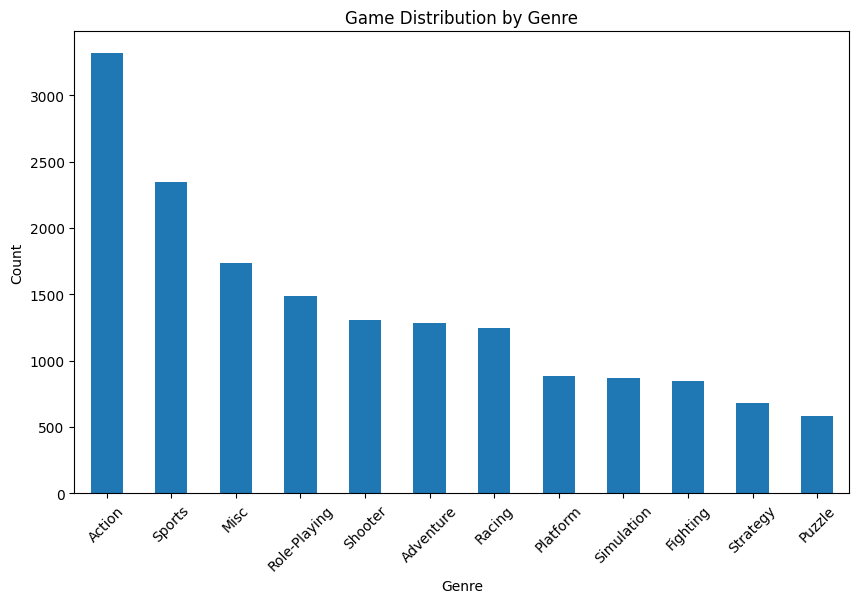

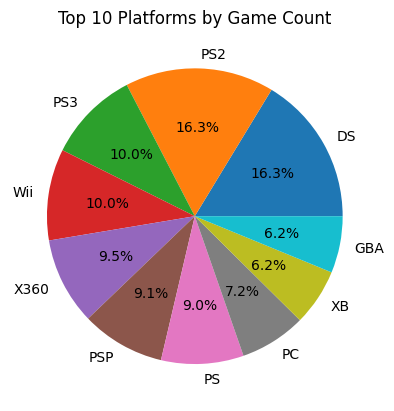

In [ ]:
# Frequency counts
print(df['Genre'].value_counts())

# Visualize with bar chart
df['Genre'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title('Game Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Pie chart for proportions
df['Platform'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Platforms by Game Count')
plt.show()
